# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

practice_dir_path = '/content/drive/MyDrive/practice/01 Basics/modules'
os.chdir(practice_dir_path)
!ls

classification.py   __init__.py		  plots.py
clustering.py	    metrics.py		  __pycache__
image_converter.py  pairwise_distance.py  utils.py


Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [ ]:
%load_ext autoreload
%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 14.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import random
from sktime.distances import euclidean_distance, dtw_distance, pairwise_distance
from sklearn.metrics import silhouette_score
import cv2
import imutils
import glob
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from math import sqrt
import importlib

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts

## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [ ]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    np.testing.assert_equal(round(dist1, 5), round(dist2, 5), 'Distances are not equal')

In [ ]:
def ED_distance(ts1: np.ndarray, ts2: np.ndarray) -> float:
    """
    Calculate the Euclidean distance

    Parameters
    ----------
    ts1: the first time series
    ts2: the second time series

    Returns
    -------
    ed_dist: euclidean distance between ts1 and ts2
    """

    if len(ts1) != len(ts2):
        raise ValueError("Длина временных рядов не совпадает")

    # Вычисляем евклидово расстояние
    diff = ts1 - ts2
    squared_diff = np.sum(diff ** 2)
    ed_dist = np.sqrt(squared_diff)

    return ed_dist

In [ ]:
LEN = 200

series1 = random_walk(LEN)
series2 = random_walk(LEN)

my_distance = ED_distance(series1, series2)
print(f"ED_distance: {my_distance}")

sktime_distance = euclidean_distance(series1, series2)
print(f"euclidean_distance: {sktime_distance}")

ED_distance: 162.82505949638096
euclidean_distance: 162.82505949638096


In [ ]:
print(f"Временной ряд 1 (первые 10 значений): {series1[:20]}")
print(f"Временной ряд 2 (первые 10 значений): {series2[:20]}")
print()

Временной ряд 1 (первые 10 значений): [ 0  1  2  1  0 -1 -2 -3 -2 -3 -4 -3 -4 -3 -2 -1  0  1  2  1]
Временной ряд 2 (первые 10 значений): [ 0 -1 -2 -1  0 -1  0  1  2  3  2  3  2  1  2  3  2  1  2  1]



### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [ ]:
def DTW_distance(ts1: np.ndarray, ts2: np.ndarray) -> float:
    """
    Calculate the normalized Euclidean distance

    Parameters
    ----------
    ts1: the first time series
    ts2: the second time series

    Returns
    -------
    norm_ed_dist: normalized Euclidean distance between ts1 and ts2s
    """

    n = len(ts1)
    m = len(ts2)

    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = (ts1[i-1] - ts2[j-1]) ** 2
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )

    return dtw_matrix[n, m]

In [ ]:
my_distance = DTW_distance(series1, series2)
print(f"DTW_distance: {my_distance}")

sktime_distance = dtw_distance(series1, series2)
print(f"Sktime dtw_distance: {sktime_distance}")


DTW_distance: 15378.0
Sktime dtw_distance: 15378.0


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [ ]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    np.testing.assert_equal(matrix1.round(5), matrix2.round(5), 'Matrices are not equal')

In [ ]:
import numpy as np

from modules.utils import z_normalize

class PairwiseDistance:
    """
    Distance matrix between time series

    Parameters
    ----------
    metric: distance metric between two time series
            Options: {euclidean, dtw}
    is_normalize: normalize or not time series
    """

    def __init__(self, metric: str = 'euclidean', is_normalize: bool = False) -> None:

        self.metric: str = metric
        self.is_normalize: bool = is_normalize


    @property
    def distance_metric(self) -> str:
        """Return the distance metric

        Returns
        -------
            string with metric which is used to calculate distances between set of time series
        """

        norm_str = ""
        if (self.is_normalize):
            norm_str = "normalized "
        else:
            norm_str = "non-normalized "

        return norm_str + self.metric + " distance"


    def _choose_distance(self):
        """ Choose distance function for calculation of matrix

        Returns
        -------
        dict_func: function reference
        """

        if self.metric == 'euclidean':
            return ED_distance
        elif self.metric == 'dtw':
            return DTW_distance
        else:
            raise ValueError(f"Unknown metric: {self.metric}. Available options: 'euclidean', 'dtw'")


    def calculate(self, input_data: np.ndarray) -> np.ndarray:
        """ Calculate distance matrix

        Parameters
        ----------
        input_data: time series set

        Returns
        -------
        matrix_values: distance matrix
        """

        matrix_shape = (input_data.shape[0], input_data.shape[0])
        matrix_values = np.zeros(shape=matrix_shape)

        if self.is_normalize:
            input_data = np.array([z_normalize(ts) for ts in input_data])

        dist_func = self._choose_distance()

        for i in range(K):
            for j in range(i + 1, K):
                distance = dist_func(input_data[i], input_data[j])
                matrix_values[i, j] = distance
                matrix_values[j, i] = distance

        return matrix_values

In [ ]:
def generate_series_array(K: int, len: int) -> np.ndarray:
    return np.array([random_walk(len) for _ in range(K)])

In [ ]:
K = 5
length = 10
time_series_array = generate_series_array(K, length)

In [ ]:
time_series_array.shape
time_series_array.shape
(5, 10)

(5, 10)

In [ ]:
print("1. Евклидово расстояние:")
my_pairwise_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
my_euclidean = my_pairwise_euclidean.calculate(time_series_array)
sktime_euclidean = pairwise_distance(time_series_array, metric='euclidean')

print("Матрица расстояний")
print(f"Наша реализация:\n{my_euclidean}")
print(f"Sktime реализация:\n{sktime_euclidean}")
print()

difference = np.abs(my_euclidean - sktime_euclidean)
print(f"Разница между матрицами:\n{difference}")
print(f"Средняя разница:\n{np.mean(difference)}")
print(f"Максимальная разница:\n{np.max(difference)}")

1. Евклидово расстояние:
Матрица расстояний
Наша реализация:
[[ 0.         16.24807681  6.32455532 17.88854382  5.29150262]
 [16.24807681  0.         21.3541565   2.82842712 12.80624847]
 [ 6.32455532 21.3541565   0.         22.8035085   9.16515139]
 [17.88854382  2.82842712 22.8035085   0.         14.        ]
 [ 5.29150262 12.80624847  9.16515139 14.          0.        ]]
Sktime реализация:
[[ 0.         16.24807681  6.32455532 17.88854382  5.29150262]
 [16.24807681  0.         21.3541565   2.82842712 12.80624847]
 [ 6.32455532 21.3541565   0.         22.8035085   9.16515139]
 [17.88854382  2.82842712 22.8035085   0.         14.        ]
 [ 5.29150262 12.80624847  9.16515139 14.          0.        ]]

Разница между матрицами:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Средняя разница:
0.0
Максимальная разница:
0.0


In [ ]:
print("2. DTW расстояние:")
my_pairwise_dtw = PairwiseDistance(metric='dtw', is_normalize=False)
my_dtw = my_pairwise_dtw.calculate(time_series_array)
sktime_dtw = pairwise_distance(time_series_array, metric='dtw')

print("Матрица расстояний")
print(f"Наша реализация:\n{my_dtw}")
print(f"Sktime реализация:\n{sktime_dtw}")
print()

difference = np.abs(my_dtw - sktime_dtw)
print(f"Разница между матрицами:\n{difference}")
print(f"Средняя разница:\n{np.mean(difference)}")
print(f"Максимальная разница:\n{np.max(difference)}")

2. DTW расстояние:
Матрица расстояний
Наша реализация:
[[  0. 250.  38. 294.   4.]
 [250.   0. 456.   2. 148.]
 [ 38. 456.   0. 518.  48.]
 [294.   2. 518.   0. 180.]
 [  4. 148.  48. 180.   0.]]
Sktime реализация:
[[  0. 250.  38. 294.   4.]
 [250.   0. 456.   2. 148.]
 [ 38. 456.   0. 518.  48.]
 [294.   2. 518.   0. 180.]
 [  4. 148.  48. 180.   0.]]

Разница между матрицами:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Средняя разница:
0.0
Максимальная разница:
0.0


### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [ ]:
url = '/content/drive/MyDrive/practice/01 Basics/datasets/part1/CBF_TRAIN.txt'

import pandas as pd

data = pd.DataFrame(read_ts(url))  # превращаем в DataFrame

labels = data.iloc[:, 0]
np_ts_set = ts_set.to_numpy()
ts_set = data.iloc[:, 1:]


/content/drive/MyDrive/practice/01 Basics/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

In [ ]:
import numpy as np
from modules.plots import plot_ts

ts_array = ts_set.to_numpy()
labels_array = labels.to_numpy()

unique_classes = np.unique(labels_array)

for cls in unique_classes:
    idx = np.where(labels_array == cls)[0][0]
    ts = ts_array[idx].reshape(1, -1)
    print(f"Class {cls} example:")
    plot_ts(ts)



Class 1.0 example:


Class 2.0 example:


Class 3.0 example:


Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from typing_extensions import Self

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


class TimeSeriesHierarchicalClustering:
    """
    Hierarchical Clustering of time series

    Parameters
    ----------
    n_clusters: number of clusters
    method: linkage criterion.
            Options: {single, complete, average, weighted}
    """

    def __init__(self, n_clusters: int = 3, method: str = 'complete') -> None:

        self.n_clusters: int = n_clusters
        self.method: str = method
        self.model: AgglomerativeClustering | None = None
        self.linkage_matrix: np.ndarray | None = None


    def _create_linkage_matrix(self) -> np.ndarray:
        """
        Build the linkage matrix

        Returns
        -------
        linkage matrix: linkage matrix
        """

        counts = np.zeros(self.model.children_.shape[0])
        n_samples = len(self.model.labels_)

        for i, merge in enumerate(self.model.children_):
            current_count = 0
            for child_idx in merge:
                if child_idx < n_samples:
                    current_count += 1  # leaf node
                else:
                    current_count += counts[child_idx - n_samples]
            counts[i] = current_count

        linkage_matrix = np.column_stack([self.model.children_, self.model.distances_, counts]).astype(float)

        return linkage_matrix


    def fit(self, distance_matrix: np.ndarray) -> Self:
        """
        Fit the agglomerative clustering model based on distance matrix

        Parameters
        ----------
        distance_matrix: distance matrix between instances of dataset with shape (ts_number, ts_number)

        Returns
        -------
        self: the fitted model
        """

        self.model = AgglomerativeClustering(
              n_clusters=self.n_clusters,
              metric='precomputed',
              linkage=self.method,
              compute_distances=True
        )

        self.labels_ = self.model.fit_predict(distance_matrix)

        self.linkage_matrix = self._create_linkage_matrix()

        return self


    def fit_predict(self, distance_matrix: np.ndarray) -> np.ndarray:
        """
        Fit the agglomerative clustering model based on distance matrix and predict classes

        Parameters
        ----------
        distance_matrix: distance matrix between instances of dataset with shape (ts_number, ts_number)

        Returns
        -------
            predicted labels
        """

        self.fit(distance_matrix)

        return self.labels_


    def _draw_timeseries_allclust(self, dx: pd.DataFrame, labels: np.ndarray, leaves: list[int], gs: gridspec.GridSpec, ts_hspace: int) -> None:
        """
        Plot time series graphs beside dendrogram

        Parameters
        ----------
        dx: timeseries data with column "y" indicating cluster number
        labels: labels of dataset's instances
        leaves: leave node names from scipy dendrogram
        gs: gridspec configurations
        ts_hspace: horizontal space in gridspec for plotting time series
        """

        prop_cycle = plt.rcParams['axes.prop_cycle']
        colors = prop_cycle.by_key()['color']
        margin = 7

        max_cluster = len(leaves)

        leaves = leaves[::-1]

        for cnt in range(len(leaves)):
            plt.subplot(gs[cnt:cnt+1, max_cluster-ts_hspace:max_cluster])
            plt.axis("off")

            leafnode = leaves[cnt]
            ts = dx[leafnode]
            ts_len = ts.shape[0] - 1

            label = int(labels[leafnode])
            color_ts = colors[label]

            plt.plot(ts, color=color_ts)
            plt.text(ts_len+margin, 0, f'class = {label}')


    def plot_dendrogram(self, df: pd.DataFrame, labels: np.ndarray, ts_hspace: int = 12, title: str = 'Dendrogram') -> None:
        """
        Draw agglomerative clustering dendrogram with timeseries graphs for all clusters.

        Parameters
        ----------
        df: dataframe with each row being the time window of readings
        labels: labels of dataset's instances
        ts_hspace: horizontal space for timeseries graph to be plotted
        title: title of dendrogram
        """

        max_cluster = len(self.linkage_matrix) + 1

        plt.figure(figsize=(12, 9))

        gs = gridspec.GridSpec(max_cluster, max_cluster)

        plt.subplot(gs[:, 0 : max_cluster - ts_hspace - 1])
        plt.xlabel("Distance")
        plt.ylabel("Cluster")
        plt.title(title, fontsize=16, weight='bold')

        ddata = dendrogram(self.linkage_matrix, orientation="left", color_threshold=sorted(self.model.distances_)[-2], show_leaf_counts=True)

        self._draw_timeseries_allclust(df, labels, ddata["leaves"], gs, ts_hspace)

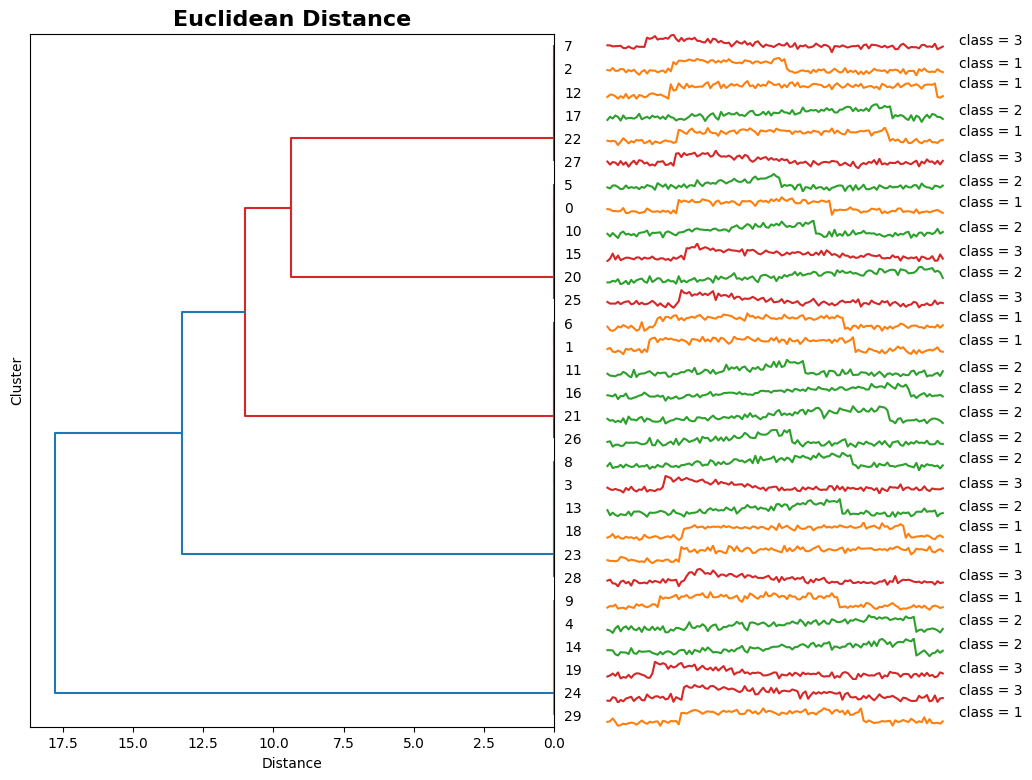

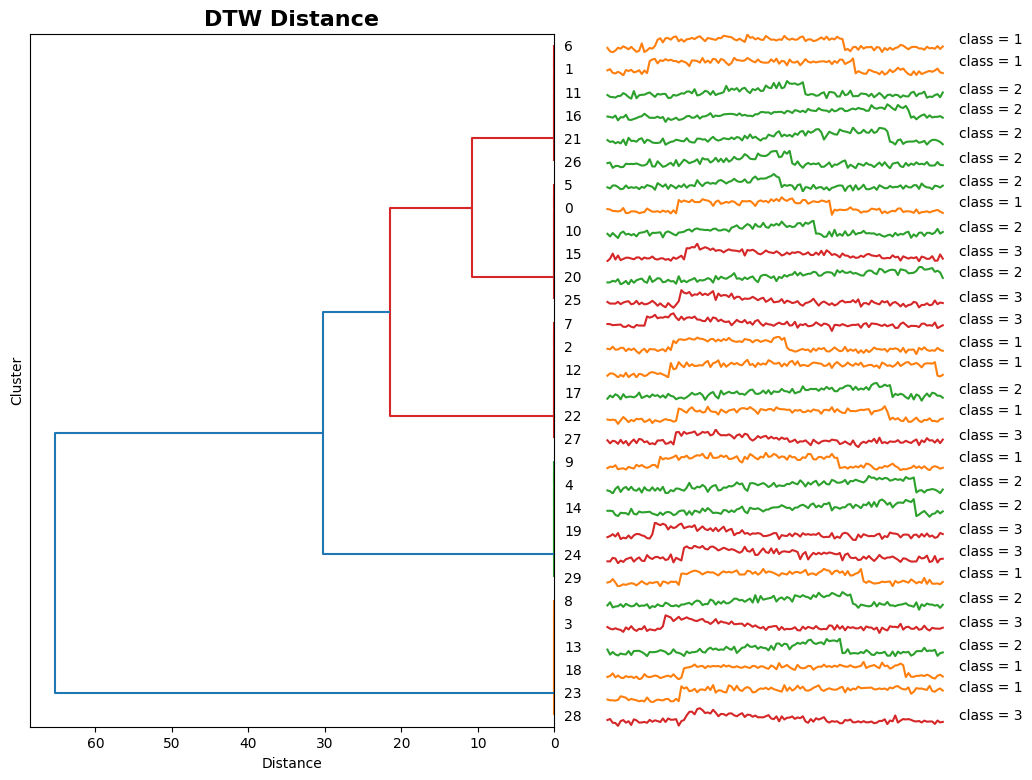

In [ ]:
euclidean_dist = PairwiseDistance(metric='euclidean')
euclidean_matrix = euclidean_dist.calculate(np_ts_set)

dtw_dist = PairwiseDistance(metric='dtw')
dtw_matrix = dtw_dist.calculate(np_ts_set)

hc_euclidean = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
hc_euclidean.fit(euclidean_matrix)

hc_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
hc_dtw.fit(dtw_matrix)

df_ts = pd.DataFrame(ts_set.T)

hc_euclidean.plot_dendrogram(
    df_ts,
    labels,
    title='Euclidean Distance'
)

hc_dtw.plot_dendrogram(
    df_ts,
    labels,
    title='DTW Distance'
)

Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [ ]:

from sklearn.metrics import silhouette_score

silhouette_euclidean = silhouette_score(
    euclidean_matrix,
    hc_euclidean.labels_,
    metric='precomputed'
)

silhouette_dtw = silhouette_score(
    dtw_matrix,
    hc_dtw.labels_,
    metric='precomputed'
)

print(f"Евклидово расстояние: {silhouette_euclidean:.4f}")
print(f"DTW расстояние: {silhouette_dtw:.4f}")

if silhouette_euclidean > silhouette_dtw:
    print("Евклидово расстояние показало лучшее качество кластеризации")
elif silhouette_dtw > silhouette_euclidean:
    print("DTW расстояние показало лучшее качество кластеризации")
else:
    print("Оба метода показали одинаковое качество")

Евклидово расстояние: 0.1069
DTW расстояние: 0.1233
DTW расстояние показало лучшее качество кластеризации


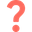
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

1. Дендрограммы

Евклидово расстояние
На первой дендрограмме видно, что кластеры формируются, но расстояния между ними относительно невелики (максимум около 18). Это говорит о том, что объекты различаются, но не слишком явно.
При этом на графиках справа можно заметить, что временные ряды одного класса (например, class = 1 или class = 2) иногда оказываются в разных ветвях дендрограммы → смешение внутри кластеров.

DTW расстояние
На второй дендрограмме видно, что структура кластеров более устойчивая: похожие временные ряды группируются вместе даже если у них смещение или временной сдвиг. Расстояния между кластерами значительно выше (до 65), что указывает на лучшее разделение.
На визуализации видно, что представители одного класса чаще оказываются в одних и тех же ветвях.

2. Силуэтный коэффициент

Евклидово расстояние: 0.1069

DTW расстояние: 0.1233

Оба значения довольно низкие (около 0.1), что говорит о том, что кластеры пересекаются и не являются идеально чёткими. Однако DTW показывает чуть лучшее качество кластеризации (0.1233 против 0.1069).

3. Почему DTW лучше в данном случае?

Евклидово расстояние сравнивает временные ряды по точкам один к одному. Даже небольшие смещения по времени (например, сигнал начался чуть раньше или позже) приводят к большим ошибкам и неверной группировке.

DTW (Dynamic Time Warping) «подгоняет» временные ряды, растягивая и сжимая их по оси времени, чтобы находить схожие формы даже при смещении или разной скорости развития сигнала.

Поэтому для кластеризации временных рядов DTW почти всегда даёт более осмысленные результаты.

4. Когда предпочтительно использовать DTW?

DTW стоит использовать, когда:

- временные ряды имеют схожую форму, но разные сдвиги или растяжения по времени (например, пики могут наступать в разное время);

- данные могут содержать неравномерные колебания или временные задержки;

- важно выявить сходство поведения сигналов, а не точное совпадение значений по индексам.

Евклидова метрика подходит, если:

- ряды хорошо выровнены по времени;

- структура данных проста и важна именно амплитуда в конкретных точках, а не форма в целом;

- нужно быстрое вычисление (DTW дороже по ресурсам).

Вывод:
В данном задании DTW расстояние показало лучший результат (и по силуэтному коэффициенту, и по дендрограмме), так как оно лучше учитывает смещения и искажения во временных рядах. Поэтому для анализа подобных данных DTW является более предпочтительной метрикой, чем евклидова.

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [ ]:
import numpy as np
from modules.utils import z_normalize  # используем готовую функцию

def norm_ED_distance(ts1: np.ndarray, ts2: np.ndarray) -> float:
    """
    Normalized Euclidean distance between two time series

    ED_norm(T1, T2) = sqrt( 2n * (1 - ( <T1,T2> - n*mu1*mu2 ) / (n*sigma1*sigma2) ) )

    Parameters
    ----------
    ts1 : np.ndarray
        First time series
    ts2 : np.ndarray
        Second time series

    Returns
    -------
    float
        Normalized Euclidean distance
    """
    ts1 = np.asarray(ts1, dtype=float).ravel()
    ts2 = np.asarray(ts2, dtype=float).ravel()

    if ts1.shape != ts2.shape:
        raise ValueError(f"Time series must have the same length, got {ts1.shape} vs {ts2.shape}")

    n = ts1.shape[0]
    mu1, mu2 = np.mean(ts1), np.mean(ts2)
    sigma1, sigma2 = np.sqrt(np.mean(ts1**2) - mu1**2), np.sqrt(np.mean(ts2**2) - mu2**2)

    if sigma1 == 0 or sigma2 == 0:
        return 0.0

    dot = np.dot(ts1, ts2)
    ed_norm = np.sqrt( 2*n * (1 - (dot - n*mu1*mu2) / (n*sigma1*sigma2)) )

    return float(ed_norm)


In [ ]:
from sktime.distances import euclidean_distance
from modules.utils import z_normalize

ts1 = z_normalize(np.random.randn(50))
ts2 = z_normalize(np.random.randn(50))

my_dist = norm_ED_distance(ts1, ts2)
sktime_dist = euclidean_distance(ts1, ts2)

print("My normalized ED distance:", my_dist)
print("sktime normalized ED distance:", sktime_dist)


My normalized ED distance: 8.366245597373798
sktime normalized ED distance: 8.366245597373798


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [ ]:
url1 = '/content/drive/MyDrive/practice/01 Basics/datasets/part2/chf10.csv'
ts1 = read_ts(url1)

url2 = '/content/drive/MyDrive/practice/01 Basics/datasets/part2/chf11.csv'
ts2 = read_ts(url2)

/content/drive/MyDrive/practice/01 Basics/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead

/content/drive/MyDrive/practice/01 Basics/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



In [ ]:
ts_set = np.concatenate((ts1, ts2), axis=1).T

In [ ]:
plot_ts(ts_set)

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [ ]:
m = 125
subs_set1 = sliding_window(ts_set[0], m, m-1)
subs_set2 = sliding_window(ts_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.

In [ ]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.

In [ ]:
pw_euc = PairwiseDistance(metric='euclidean', is_normalize=False)
matrix_euc = pw_euc.calculate(subs_set)
print("Euclidean distance matrix:\n", matrix_euc)

# Нормализованный Евклид
pw_euc_norm = PairwiseDistance(metric='euclidean', is_normalize=True)
matrix_euc_norm = pw_euc_norm.calculate(subs_set)
print("Normalized Euclidean distance matrix:\n", matrix_euc_norm)

Euclidean distance matrix:
 [[0.         1.15785362 1.11661318 1.69897028 2.02302373 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [1.15785362 0.         0.75069967 1.58782083 2.15908545 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [1.11661318 0.75069967 0.         0.97369143 1.54377783 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [1.69897028 1.58782083 0.97369143 0.        

In [ ]:
print(subs_set.shape)


(30, 125)


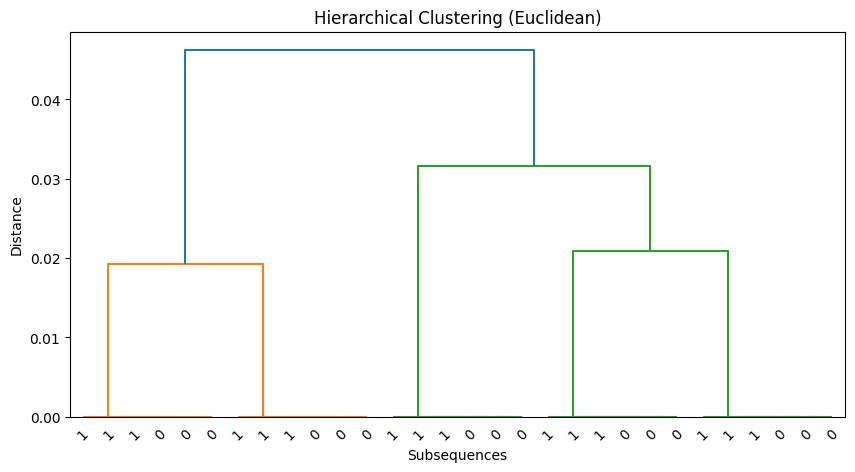

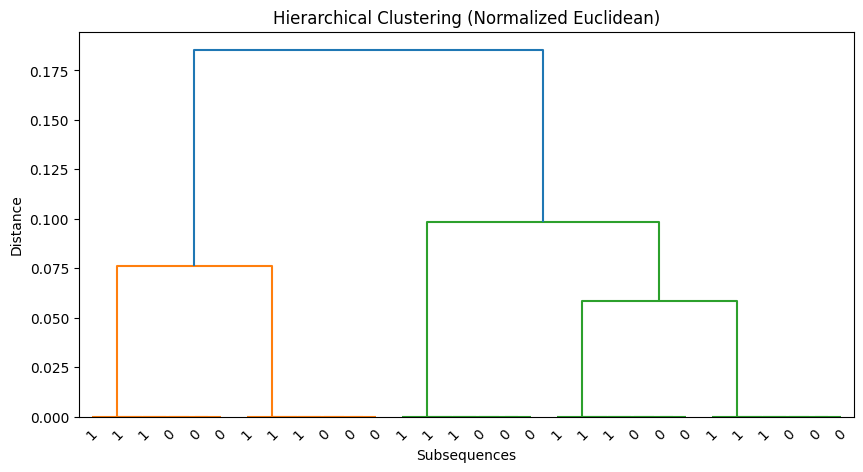

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
def plot_dendrogram(matrix, title="Dendrogram"):
    # linkage требует condensed distance matrix
    from scipy.spatial.distance import squareform
    condensed = squareform(matrix)
    Z = linkage(condensed, method='average')  # среднее связывание
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=labels)
    plt.title(title)
    plt.xlabel("Subsequences")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(matrix_euc, title="Hierarchical Clustering (Euclidean)")
plot_dendrogram(matrix_euc_norm, title="Hierarchical Clustering (Normalized Euclidean)")

Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

def get_cluster_labels(matrix, n_clusters=3):
    condensed = squareform(matrix)
    Z = linkage(condensed, method='average')
    cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    return cluster_labels

hc_euc_labels = get_cluster_labels(matrix_euc, n_clusters=3)

hc_euc_norm_labels = get_cluster_labels(matrix_euc_norm, n_clusters=3)

silhouette_euc = silhouette_score(matrix_euc, hc_euc_labels, metric='precomputed')
silhouette_euc_norm = silhouette_score(matrix_euc_norm, hc_euc_norm_labels, metric='precomputed')

print(f"Силуэт (без нормализации): {silhouette_euc:.4f}")
print(f"Силуэт (с нормализацией): {silhouette_euc_norm:.4f}")

if silhouette_euc > silhouette_euc_norm:
    print("Без нормализации кластеризация лучше")
elif silhouette_euc_norm > silhouette_euc:
    print("С нормализацией кластеризация лучше")
else:
    print("Оба метода дали одинаковое качество кластеризации")


Силуэт (без нормализации): 0.1260
Силуэт (с нормализацией): 0.1262
С нормализацией кластеризация лучше


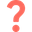
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

Разница очень маленькая (0.0002), но формально с нормализацией коэффициент чуть выше, что говорит о минимальном улучшении качества кластеризации.

Вывод:

z-нормализация немного повысила качество кластеризации, но эффект в данном случае незначительный. Она особенно полезна, когда отдельные временные ряды сильно различаются по амплитуде.

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}

\
<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

Изображение успешно загружено. Форма: (1442, 867, 3)


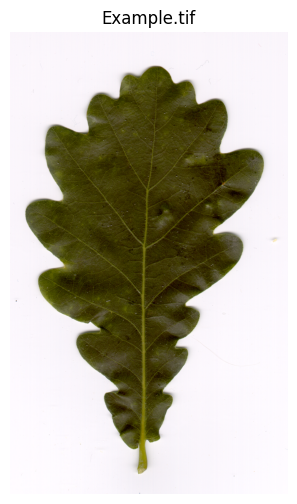

In [ ]:
import cv2
from matplotlib import pyplot as plt

image_path = '/content/drive/MyDrive/practice/01 Basics/datasets/part3/example.tif'

img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if img is None:
    print("Ошибка: изображение не найдено или не удалось загрузить.")
else:
    print("Изображение успешно загружено. Форма:", img.shape)

    if len(img.shape) == 3 and img.shape[2] == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    plt.figure(figsize=(8, 6))
    if len(img_rgb.shape) == 2:
        plt.imshow(img_rgb, cmap='gray')
    else:
        plt.imshow(img_rgb)
    plt.title("Example.tif")
    plt.axis('off')
    plt.show()


За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


Изображение успешно загружено. Форма: (1442, 867, 3)


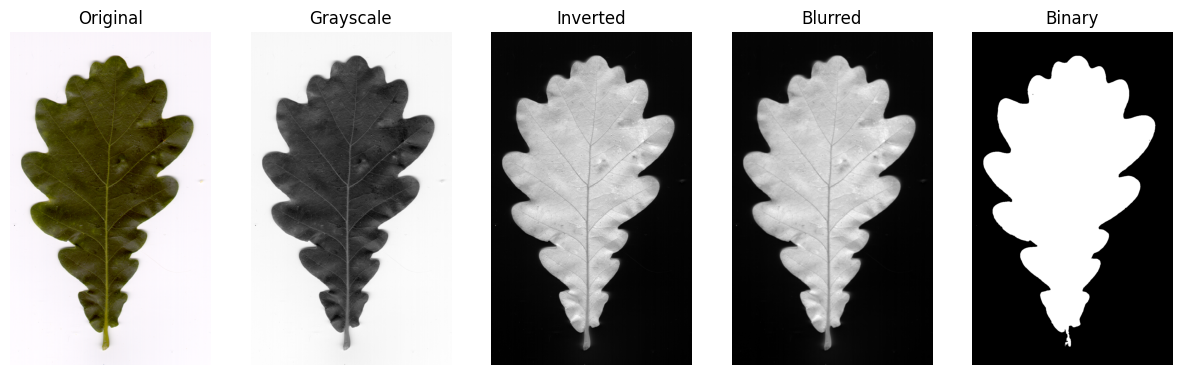

In [ ]:
import cv2
from matplotlib import pyplot as plt

image_path = '/content/drive/MyDrive/practice/01 Basics/datasets/part3/example.tif'

img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

if img is None:
    print("Ошибка: изображение не найдено или не удалось загрузить.")
else:
    print("Изображение успешно загружено. Форма:", img.shape)

    if len(img.shape) == 3 and img.shape[2] == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    inv = cv2.bitwise_not(gray)
    blur = cv2.GaussianBlur(inv, (5,5), 0)
    _, binary = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)
    titles = ['Original', 'Grayscale', 'Inverted', 'Blurred', 'Binary']
    images = [img_rgb, gray, inv, blur, binary]

    plt.figure(figsize=(15, 5))
    for i, (title, image) in enumerate(zip(titles, images)):
        plt.subplot(1, 5, i+1)
        if len(image.shape) == 2:  # grayscale
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(image)
        plt.title(title)
        plt.axis('off')
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import math
import cv2
import imutils
from google.colab.patches import cv2_imshow


class Image2TimeSeries:
    """
    Converter from image to time series by angle-based method

    Parameters
    ----------
    angle_step: angle step for finding the contour points
    """

    def __init__(self, angle_step: int = 10) -> None:
        self.angle_step: int = angle_step


    def _img_preprocess(self, img: np.ndarray) -> np.ndarray:
      """
    Preprocess the raw image: convert to grayscale, inverse, blur slightly, and threshold it
    """
      gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      inv = cv2.bitwise_not(gray)
      blur = cv2.GaussianBlur(inv, (5,5), 0)
      _, prep_img = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

      return prep_img


    def _get_contour(self, img: np.ndarray) -> np.ndarray:
        """
        Find the largest contour in the preprocessed image

        Parameters
        ----------
        img: preprocessed image

        Returns
        -------
        contour: object contour
        """

        contours, hierarchy = cv2.findContours(img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour = [cnt for cnt in contours if cv2.contourArea(cnt) > 500][0]

        return contour


    def _get_center(self, contour: np.ndarray) -> tuple[float, float]:
        """
        Compute the object center

        Parameters
        ----------
        contour: object contour

        Returns
        -------
            coordinates of the object center
        """

        M = cv2.moments(contour)
        center_x = int(M["m10"] / M["m00"])
        center_y = int(M["m01"] / M["m00"])

        return (center_x, center_y)


    def _find_nearest_idx(self, array: np.ndarray, value: int) -> int:
        """
        Find index of element that is the nearest to the defined value

        Parameters
        ----------
        array: array of values
        value: defined value

        Returns
        -------
        idx: index of element that is the nearest to the defined value
        """

        array = np.asarray(array)
        idx = (np.abs(array - value)).argmin()

        return idx


    def _get_coordinates_at_angle(self, contour: np.ndarray, center: tuple[float, float], angle: int) -> np.ndarray:
        """
        Find one point on contour that are located at the angle

        Parameters
        ----------
        contour: object contour
        center: object center
        angle: angle

        Returns
        -------
            coordinates of one point on the contour
        """

        angles = np.rad2deg(np.arctan2(*(center - contour).T))
        angles = np.where(angles < -90, angles + 450, angles + 90)
        found = np.rint(angles) == angle

        if np.any(found):
            return contour[found][0]
        else:
            idx = self._find_nearest_idx(angles, angle)
            return contour[idx]


    def _get_edge_coordinates(self, contour: np.ndarray, center: tuple[float, float]) -> list[np.ndarray]:
        """
        Find points on contour that are located from each other at the angle step

        Parameters
        ----------
        contour: object contour
        center: object center

        Returns
        -------
        edge_coordinates: coordinates of the object center
        """

        edge_coordinates = []
        for angle in range(0, 360, self.angle_step):
            pt = self._get_coordinates_at_angle(contour, center, angle)
            if np.any(pt):
                edge_coordinates.append(pt)

        return edge_coordinates


    def _img_show(self, img: np.ndarray, contour: np.ndarray, edge_coordinates: list[np.ndarray], center: tuple[float, float]) -> None:
        """
        Draw the raw image with contour, center of the shape on the image and rais from starting center

        Parameters
        ----------
        img: raw image
        contour: object contour
        edge_coordinates: contour points
        center: object center
        """

        cv2.drawContours(img, [contour], -1, (0, 255, 0), 6)
        cv2.circle(img, center, 7, (255, 255, 255), -1)
        cv2.putText(img, "center", (center[0]-20, center[1]-20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 6)
        for i in range(len(edge_coordinates)):
            cv2.drawContours(img, np.array([[center, edge_coordinates[i]]]), -1, (255, 0, 255), 4)

        cv2_imshow(imutils.resize(img, width=200))


    def convert(self, img: np.ndarray, is_visualize: bool = False) -> np.ndarray:
        """
        Convert image to time series by angle-based method

        Parameters
        ----------
        img: input image
        is_visualize: visualize or not image with contours, center and rais from starting center

        Returns
        -------
        ts: time series representation
        """

        ts = []

        prep_img = self._img_preprocess(img)
        contour = self._get_contour(prep_img)
        center = self._get_center(contour)
        edge_coordinates = self._get_edge_coordinates(contour.squeeze(), center)

        if (is_visualize):
            self._img_show(img.copy(), contour, edge_coordinates, center)

        for coord in edge_coordinates:
            #dist = math.sqrt((coord[0] - center[0])**2 + (coord[1] - center[1])**2)
            dist = math.fabs(coord[0] - center[0]) + math.fabs(coord[1] - center[1])
            ts.append(dist)

        return np.array(ts)


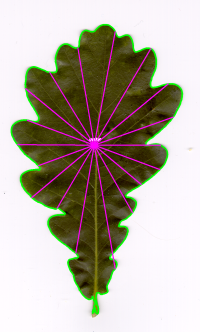

In [ ]:
angle_step = 20
converter = Image2TimeSeries(angle_step=angle_step)
ts = converter.convert(img, is_visualize=True)
plot_ts(np.array([ts]), "Time series representation of image")

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [ ]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [ ]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [ ]:
train_set_path = "/content/drive/MyDrive/practice/01 Basics/datasets/part3/train_set_leaves/*.tif"
test_set_path = "/content/drive/MyDrive/practice/01 Basics/datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = '/content/drive/MyDrive/practice/01 Basics/datasets/part3/train_set_leaves/train_label.csv'
test_label_path = '/content/drive/MyDrive/practice/01 Basics/datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

/content/drive/MyDrive/practice/01 Basics/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead

/content/drive/MyDrive/practice/01 Basics/modules/utils.py:20: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



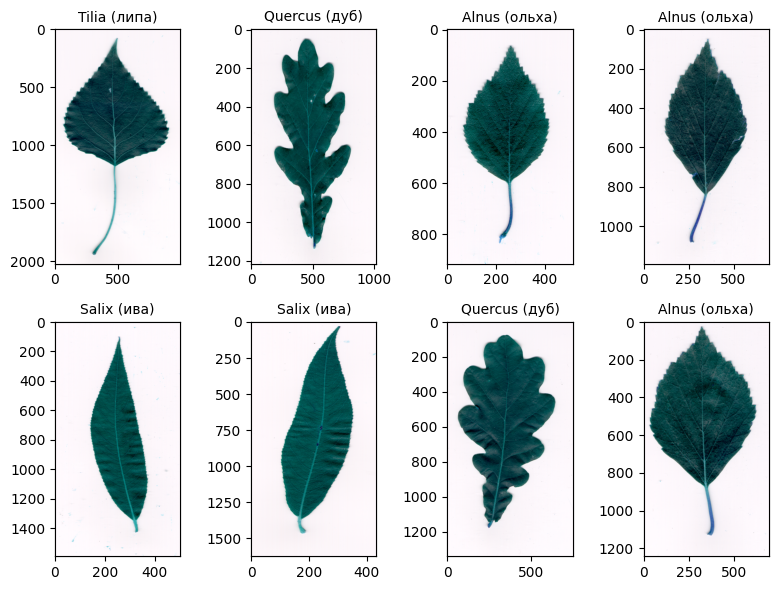

In [ ]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  

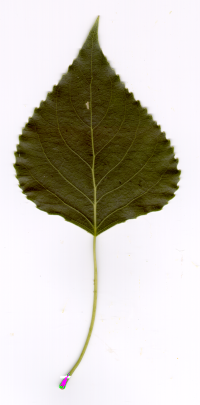

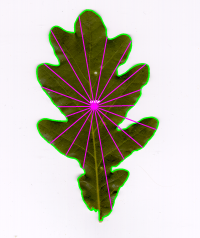

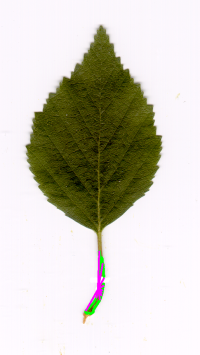

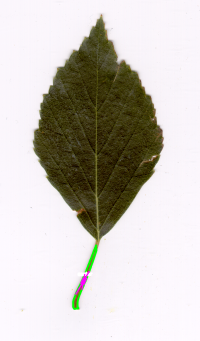

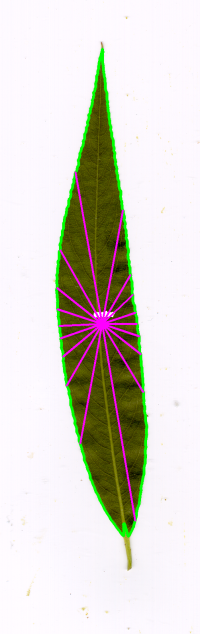

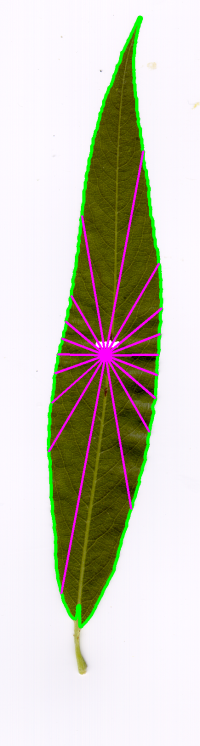

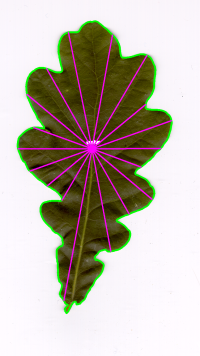

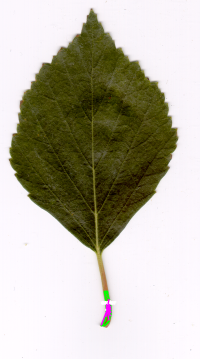

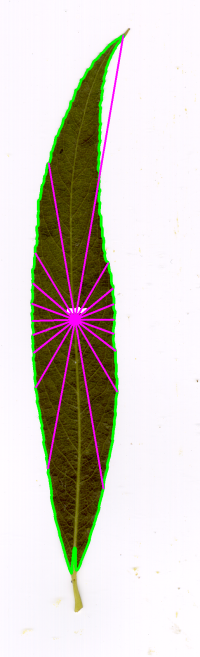

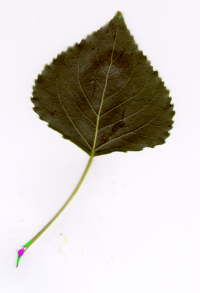

Train TS shape: (10, 18)
Test TS shape: (10, 18)


In [ ]:
angle_step = 20
converter = Image2TimeSeries(angle_step=angle_step)

def images_to_timeseries_with_plot(img_list, labels=None, class_names=None, visualize=False):
    """
    Преобразование изображений в временные ряды с опциональной визуализацией.

    Parameters:
    - img_list: список изображений
    - labels: список меток для изображений (для подписи класса)
    - class_names: список названий классов
    - visualize: показывать изображения и временные ряды или нет

    Returns:
    - ts_array: массив временных рядов
    """
    ts_list = []

    for idx, img in enumerate(img_list):
        ts = converter.convert(img, is_visualize=visualize)
        ts_list.append(ts)

        if visualize:
            title = None
            if labels is not None and class_names is not None:
                title = f"Class: {class_names[labels[idx]]}"
            plot_ts(np.array([ts]), f"Time series representation of image {idx+1}" + (f"\n{title}" if title else ""))

    return np.array(ts_list)

train_ts = images_to_timeseries_with_plot(train_images[:10], train_labels[:10], class_names, visualize=True)
test_ts = images_to_timeseries_with_plot(test_images[:10], visualize=False)

print("Train TS shape:", train_ts.shape)
print("Test TS shape:", test_ts.shape)


Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [ ]:
import numpy as np
from collections import Counter
from modules.metrics import *
from modules.utils import z_normalize

default_metrics_params = {'euclidean': {'normalize': True},
                         'dtw': {'normalize': True, 'r': 0.05}
                         }

class TimeSeriesKNN:
    def __init__(self, n_neighbors: int = 3, metric: str = 'euclidean', metric_params: dict | None = None) -> None:
        self.n_neighbors: int = n_neighbors
        self.metric: str = metric
        self.metric_params: dict | None = default_metrics_params[metric].copy()
        if metric_params is not None:
            self.metric_params.update(metric_params)

    def fit(self, X_train: np.ndarray, Y_train: np.ndarray) -> 'TimeSeriesKNN':
        """
        Просто сохраняем обучающие данные и метки
        """
        self.X_train = X_train
        self.Y_train = Y_train
        return self

    def _distance(self, x_train: np.ndarray, x_test: np.ndarray) -> float:
        """
        Вычисление расстояния между временными рядами
        """
        if self.metric == 'euclidean':
            if self.metric_params.get('normalize', True):
                x_train = z_normalize(x_train)
                x_test = z_normalize(x_test)
            dist = np.linalg.norm(x_train - x_test)
        elif self.metric == 'dtw':
            r = self.metric_params.get('r', 0.05)
            dist = dtw_distance(x_train, x_test, r=r, normalize=self.metric_params.get('normalize', True))
        else:
            raise ValueError(f"Unknown metric: {self.metric}")
        return dist

    def _find_neighbors(self, x_test: np.ndarray) -> list[tuple[float, int]]:
        """
        Находим k ближайших соседей
        """
        distances = []
        for i in range(len(self.X_train)):
            dist = self._distance(self.X_train[i], x_test)
            distances.append((dist, self.Y_train[i]))
        distances.sort(key=lambda x: x[0])
        return distances[:self.n_neighbors]

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        """
        Предсказание классов для тестовой выборки
        """
        y_pred = []
        for x in X_test:
            neighbors = self._find_neighbors(x)
            neighbor_labels = [label for _, label in neighbors]
            most_common = Counter(neighbor_labels).most_common(1)[0][0]
            y_pred.append(most_common)
        return np.array(y_pred)


def calculate_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Точность классификации
    """
    score = np.sum(y_true == y_pred) / len(y_true)
    return score


In [ ]:
y_test_correct = test_labels[:10]  # или [:len(test_ts)]


In [ ]:
n_neighbors = 6

y_test_correct = test_labels[:len(test_ts)]

metric = 'euclidean'
metric_params = {'normalize': True}

knn_euc = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_euc.fit(train_ts, train_labels)
y_pred_euc = knn_euc.predict(test_ts)
accuracy_euc = calculate_accuracy(y_test_correct, y_pred_euc)
print(f"Accuracy (Euclidean, k={n_neighbors}): {accuracy_euc:.4f}")
metric = 'dtw'
metric_params = {'normalize': True, 'r': 0.05}
knn_dtw = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_dtw.fit(train_ts, train_labels)
y_pred_dtw = knn_dtw.predict(test_ts)

accuracy_dtw = calculate_accuracy(y_test_correct, y_pred_dtw)
print(f"Accuracy (DTW, k={n_neighbors}): {accuracy_dtw:.4f}")

if accuracy_euc > accuracy_dtw:
    print("Лучший результат показала Евклидова метрика")
elif accuracy_dtw > accuracy_euc:
    print("Лучший результат показала DTW метрика")
else:
    print("Обе метрики показали одинаковый результат")


Accuracy (Euclidean, k=6): 0.3000
Accuracy (DTW, k=6): 0.5000
Лучший результат показала DTW метрика


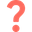
Проанализируйте результаты и сделайте выводы.

По результатам можем наблюдать, что метрика Евклида (Euclidean) имеет точность 30%, а метрика DTW (Dynamic Time Warping) - точность 50%, что позволяет сделать вывод, что наилучший результат показала именно вторая метрика.

Низкая точность при Евклидовой метрике может быть вызвана чувствительностью к смещениям и растяжением во временных рядах. Даже если форма сигнала похожа, небольшие сдвиги или масштабные изменения могут сильно увеличивать расстояние между рядами одного класса, что приводит к ошибочной классификации.

DTW же позволяет "выравнивать" временные ряды по времени, компенсируя локальные сдвиги и растяжения.Это особенно полезно для изображений листьев, где контуры и их временные представления могут немного различаться в масштабе или ориентации. Поэтому DTW лучше справляется с классификацией таких рядов.

DTW лучше учитывает временные искажения сигналов, что делает его предпочтительным для задач классификации временных рядов, особенно при работе с изображениями листьев, где возможны небольшие вариации контуров.

Евклидово расстояние проще и быстрее в вычислении, но подходит только для случаев, когда временные ряды выровнены и не содержат сдвигов.